In [47]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.formula.api as smf

In [48]:
auto=pd.read_csv('Auto.csv')


In [49]:
auto['horsepower']=pd.to_numeric(auto['horsepower'],errors='coerce')

In [50]:
equation='mpg~horsepower'

In [51]:
model=smf.ols(formula=equation,data=auto).fit()

In [52]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           7.03e-81
Time:                        23:06:53   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.0

since f statistic is 599.7 that is much greater than 1 to establish that there is some relation between the response and predictor

the r2 is 0.606 so predictors are able to answer 60.6% of the response rest is variance and other predictors
since the coefficient of predictor is -0.1578 that is <0 therefore,relationship is negative

In [53]:
new_df=pd.DataFrame({'horsepower':[98]})
prediction=model.get_prediction(new_df)
predictiontable=prediction.summary_frame(alpha=0.05)
print(predictiontable)

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  24.467077  0.251262      23.973079      24.961075     14.809396   

   obs_ci_upper  
0     34.124758  


24.467077 is the predicted mpg and amd the confidence interval is[23.973079,24.961075] and prediction interval is[14.809396,34.124758]

In [54]:
model.params

Intercept     39.935861
horsepower    -0.157845
dtype: float64

In [55]:
def abline(ax,b,m,*args):
    "Add a line with slope m and intercept b"
    xlim=ax.get_xlim()
    ylim=[m*xlim[0]+b,m*xlim[1]+b]
    ax.plot(xlim,ylim,*args)


C:\Users\Abhinav Mishra\AppData\Local\Temp\ipykernel_12896\932058047.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax,model.params[0],model.params[1],'r')


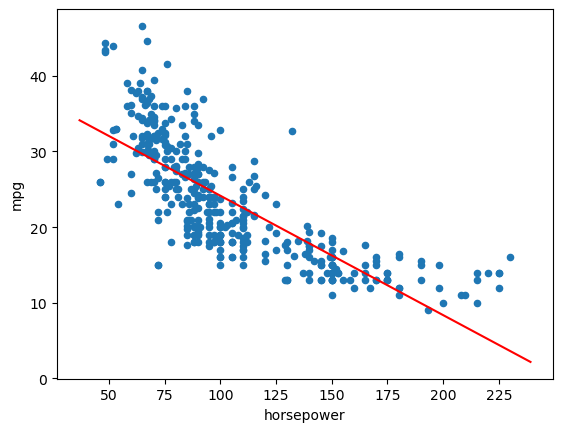

In [56]:
ax=auto.plot.scatter('horsepower','mpg')
abline(ax,model.params[0],model.params[1],'r')

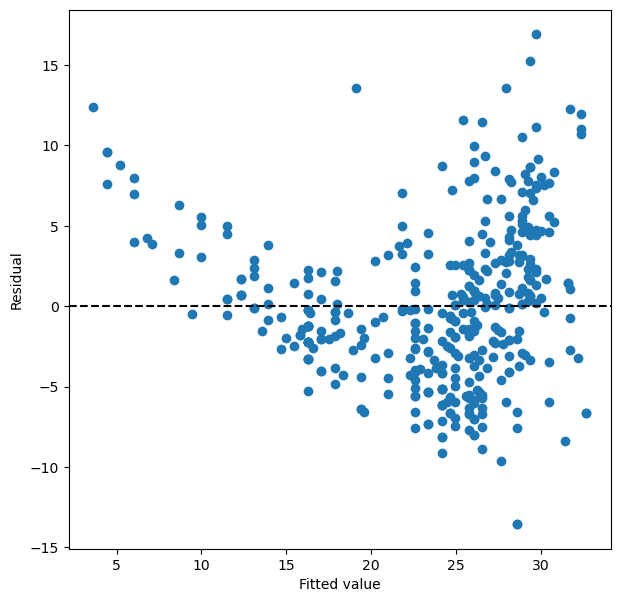

In [57]:
ax=subplots(figsize=(7,7))[1]
ax.scatter(model.fittedvalues,model.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0,c='k',ls='--')

a certain U shaped pattern can be observed the Residual is not uniformly distributed over the fitted value,this proves the relationship between horsepower and MPG is mathematically non-linear. The basic straight-line OLS model is failing here.

since the mpg horsepower scatter plot shows certain curve trend and the residual fittedvalue graph also shows evidence of non linearity,therfore using polynomial expression may yield better result

In [63]:
equation2='mpg~horsepower+I(horsepower**2)'

In [64]:
model_poly=smf.ols(formula=equation2,data=auto).fit()

In [65]:
print(model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           5.40e-99
Time:                        23:12:55   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             56.9001      1

the t statsitic of horsepower**2 is significant and p value is nearly 0 so it cannot be discarded 

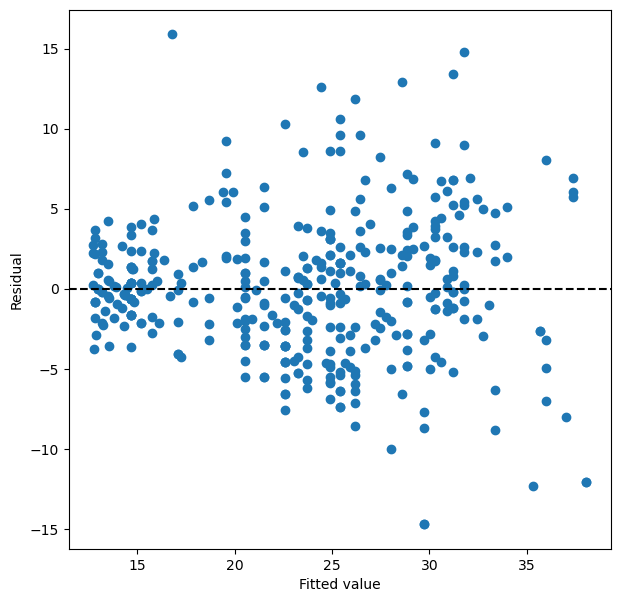

In [66]:
ax=subplots(figsize=(7,7))[1]
ax.scatter(model_poly.fittedvalues,model_poly.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0,c='k',ls='--')

we can clearly see that the U-shape has been flattened and the variance of the residuals is much more randomly distributed,
proving our quadratic structural fix worked perfectly